<a href="https://colab.research.google.com/github/jiyanshud22/Saltmine-Auto-Zoning-and-Stacking/blob/main/Zoning_using_Priority_based_Greedy_%2B_Graph_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Priority-Ordered Greedy Placement + Graph-Based Clustering

Implements 4-step zoning workflow:
1. Positioning Rule (Scatter Graph)
2. Zone Splitting Logic
3. Geometric Sizing Logic
4. Zone Boundary Definition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle, FancyBboxPatch
from collections import defaultdict, Counter
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Set, Optional
import json
from scipy.spatial import distance_matrix
from scipy.optimize import linear_sum_assignment

# =============================================================================
# DATA STRUCTURES
# =============================================================================

@dataclass
class Block:
    """Building block with all properties"""
    block_id: int
    block_name: str
    spacemix: str  # ME, WE, Support, Speciality, US
    department: str
    floor: str
    area: float
    circulation: float
    bundle_tag: str
    typical: bool = True
    open_closed: str = "Open"
    proximity_core: int = 0  # -1, 0, 1 (avoid, neutral, prefer)
    proximity_window: int = 0
    proximity_entry: int = 0
    travel_group: str = None
    grid_x: int = None
    grid_y: int = None

    @property
    def total_area(self):
        return self.area + self.circulation


@dataclass
class Core:
    """Core/anchor position on grid"""
    name: str
    x: int
    y: int
    width: int
    height: int
    core_type: str = "main"  # main, secondary, vertical_shaft


@dataclass
class FloorPlate:
    """Represents the floor plate geometry"""
    width: int  # grid units
    height: int  # grid units
    cores: List[Core] = field(default_factory=list)
    anchors: List[Tuple[int, int]] = field(default_factory=list)  # Window/perimeter anchors

    def get_perimeter_cells(self) -> Set[Tuple[int, int]]:
        """Get all perimeter/window cells"""
        perimeter = set()
        # Top and bottom
        for x in range(self.width):
            perimeter.add((x, 0))
            perimeter.add((x, self.height - 1))
        # Left and right
        for y in range(self.height):
            perimeter.add((0, y))
            perimeter.add((self.width - 1, y))
        return perimeter

    def get_core_cells(self) -> Set[Tuple[int, int]]:
        """Get all cells occupied by cores"""
        core_cells = set()
        for core in self.cores:
            for x in range(core.x, core.x + core.width):
                for y in range(core.y, core.y + core.height):
                    core_cells.add((x, y))
        return core_cells

    def get_available_cells(self) -> Set[Tuple[int, int]]:
        """Get all available cells (not core)"""
        all_cells = {(x, y) for x in range(self.width) for y in range(self.height)}
        return all_cells - self.get_core_cells()


@dataclass
class Zone:
    """A zoned area containing blocks"""
    zone_id: str
    blocks: List[Block]
    grid_cells: Set[Tuple[int, int]] = field(default_factory=set)
    color: str = "#CCCCCC"

    @property
    def spacemix_primary(self) -> str:
        """Primary spacemix type"""
        if not self.blocks:
            return "Unknown"
        counter = Counter([b.spacemix for b in self.blocks])
        return counter.most_common(1)[0][0]

    @property
    def total_area(self) -> float:
        return sum(b.total_area for b in self.blocks)

    @property
    def department_primary(self) -> str:
        if not self.blocks:
            return "Unknown"
        counter = Counter([b.department for b in self.blocks])
        return counter.most_common(1)[0][0]

    def get_bounds(self) -> Tuple[int, int, int, int]:
        """Get bounding box (min_x, min_y, max_x, max_y)"""
        if not self.grid_cells:
            return (0, 0, 0, 0)
        xs = [x for x, y in self.grid_cells]
        ys = [y for x, y in self.grid_cells]
        return (min(xs), min(ys), max(xs), max(ys))

    def get_centroid(self) -> Tuple[float, float]:
        """Get centroid of zone"""
        if not self.grid_cells:
            return (0, 0)
        xs = [x for x, y in self.grid_cells]
        ys = [y for x, y in self.grid_cells]
        return (np.mean(xs), np.mean(ys))


# =============================================================================
# STEP 1: POSITIONING RULE (SCATTER GRAPH)
# =============================================================================

class ScatterGraphPositioner:
    """
    Positions blocks on a grid based on:
    - Proximity to cores, windows, entry
    - Block-to-block adjacency
    - Department clustering
    - Travel distance groups
    """

    def __init__(self, floor_plate: FloorPlate):
        self.floor_plate = floor_plate
        self.perimeter = floor_plate.get_perimeter_cells()
        self.core_cells = floor_plate.get_core_cells()
        self.available_cells = floor_plate.get_available_cells()

    def position_blocks(self, blocks: List[Block],
                       prioritize_destinations: bool = True) -> Dict[int, Tuple[int, int]]:
        """
        Main positioning algorithm following the workflow:
        1. Place destination blocks by proximity/adjacency
        2. Place typical specialty blocks
        3. Place support superblocks
        4. Place concentrated bundles
        5. Place ME-WE bundles by travel distance
        """
        positions = {}
        used_cells = set()

        # Separate blocks by category
        destination_blocks = [b for b in blocks if 'Destination' in b.bundle_tag or b.spacemix == 'US']
        specialty_blocks = [b for b in blocks if b.spacemix == 'Speciality' and b not in destination_blocks]
        support_blocks = [b for b in blocks if b.spacemix == 'Support']
        me_blocks = [b for b in blocks if b.spacemix == 'ME']
        we_blocks = [b for b in blocks if b.spacemix == 'WE']

        print(f"  Positioning {len(destination_blocks)} destination blocks...")
        positions, used_cells = self._place_destination_blocks(
            destination_blocks, positions, used_cells
        )

        print(f"  Positioning {len(specialty_blocks)} specialty blocks...")
        positions, used_cells = self._place_specialty_blocks(
            specialty_blocks, positions, used_cells
        )

        print(f"  Positioning {len(support_blocks)} support blocks...")
        positions, used_cells = self._place_support_blocks(
            support_blocks, positions, used_cells
        )

        print(f"  Positioning {len(me_blocks)} ME blocks...")
        positions, used_cells = self._place_me_we_blocks(
            me_blocks, positions, used_cells, prefer_window=True
        )

        print(f"  Positioning {len(we_blocks)} WE blocks...")
        positions, used_cells = self._place_me_we_blocks(
            we_blocks, positions, used_cells, prefer_window=True
        )

        # Assign positions to blocks
        for block in blocks:
            if block.block_id in positions:
                block.grid_x, block.grid_y = positions[block.block_id]

        print(f"  Total positioned: {len(positions)}/{len(blocks)}")
        return positions

    def _place_destination_blocks(self, blocks: List[Block],
                                  positions: Dict, used_cells: Set) -> Tuple[Dict, Set]:
        """Place destination/US blocks near entry points"""
        # Sort by proximity preference to entry
        blocks_sorted = sorted(blocks, key=lambda b: -b.proximity_entry)

        for block in blocks_sorted:
            best_cell = self._find_best_cell(
                used_cells,
                prefer_perimeter=True,
                prefer_core_adjacent=False,
                existing_positions=positions
            )
            if best_cell:
                positions[block.block_id] = best_cell
                used_cells.add(best_cell)

        return positions, used_cells

    def _place_specialty_blocks(self, blocks: List[Block],
                                positions: Dict, used_cells: Set) -> Tuple[Dict, Set]:
        """Place specialty blocks with specific requirements"""
        for block in blocks:
            # Specialty blocks often need specific locations
            prefer_core = block.proximity_core > 0

            best_cell = self._find_best_cell(
                used_cells,
                prefer_perimeter=False,
                prefer_core_adjacent=prefer_core,
                existing_positions=positions
            )
            if best_cell:
                positions[block.block_id] = best_cell
                used_cells.add(best_cell)

        return positions, used_cells

    def _place_support_blocks(self, blocks: List[Block],
                             positions: Dict, used_cells: Set) -> Tuple[Dict, Set]:
        """Place support blocks (meeting rooms, huddle, etc.)"""
        # Group by department for clustering
        by_dept = defaultdict(list)
        for block in blocks:
            by_dept[block.department].append(block)

        for dept, dept_blocks in by_dept.items():
            # Find a region for this department
            for block in dept_blocks:
                best_cell = self._find_best_cell(
                    used_cells,
                    prefer_perimeter=False,
                    prefer_core_adjacent=True,
                    existing_positions=positions,
                    cluster_with_dept=dept
                )
                if best_cell:
                    positions[block.block_id] = best_cell
                    used_cells.add(best_cell)

        return positions, used_cells

    def _place_me_we_blocks(self, blocks: List[Block],
                           positions: Dict, used_cells: Set,
                           prefer_window: bool = True) -> Tuple[Dict, Set]:
        """Place ME/WE blocks near windows and clustered by department"""
        # Group by department and travel group
        by_dept = defaultdict(list)
        for block in blocks:
            by_dept[block.department].append(block)

        for dept, dept_blocks in by_dept.items():
            # Sort by travel group to keep groups together
            dept_blocks.sort(key=lambda b: b.travel_group or "")

            for block in dept_blocks:
                best_cell = self._find_best_cell(
                    used_cells,
                    prefer_perimeter=prefer_window and block.proximity_window > 0,
                    prefer_core_adjacent=False,
                    existing_positions=positions,
                    cluster_with_dept=dept
                )
                if best_cell:
                    positions[block.block_id] = best_cell
                    used_cells.add(best_cell)

        return positions, used_cells

    def _find_best_cell(self, used_cells: Set,
                       prefer_perimeter: bool = False,
                       prefer_core_adjacent: bool = False,
                       existing_positions: Dict = None,
                       cluster_with_dept: str = None) -> Optional[Tuple[int, int]]:
        """Find best available cell based on preferences"""
        available = self.available_cells - used_cells

        if not available:
            return None

        # Score each cell
        best_cell = None
        best_score = -float('inf')

        for cell in available:
            score = 0

            # Preference 1: Perimeter (window access)
            if prefer_perimeter and cell in self.perimeter:
                score += 100

            # Preference 2: Core adjacency
            if prefer_core_adjacent:
                if self._is_adjacent_to_core(cell):
                    score += 80
            elif not prefer_core_adjacent:
                # Avoid core if not preferred
                if self._is_adjacent_to_core(cell):
                    score -= 50

            # Preference 3: Cluster with existing blocks of same department
            if cluster_with_dept and existing_positions:
                dept_proximity = self._get_department_proximity(cell, existing_positions, cluster_with_dept)
                score += dept_proximity * 50

            # Preference 4: Avoid isolated cells
            neighbor_count = self._count_occupied_neighbors(cell, used_cells)
            score += neighbor_count * 10

            if score > best_score:
                best_score = score
                best_cell = cell

        return best_cell

    def _is_adjacent_to_core(self, cell: Tuple[int, int]) -> bool:
        """Check if cell is adjacent to a core"""
        x, y = cell
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if (x + dx, y + dy) in self.core_cells:
                    return True
        return False

    def _count_occupied_neighbors(self, cell: Tuple[int, int], used_cells: Set) -> int:
        """Count occupied neighbor cells"""
        x, y = cell
        count = 0
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                if (x + dx, y + dy) in used_cells:
                    count += 1
        return count

    def _get_department_proximity(self, cell: Tuple[int, int],
                                  existing_positions: Dict,
                                  target_dept: str) -> float:
        """Get proximity score to blocks of target department"""
        # This is simplified - in reality would check block departments
        # For now, check distance to nearest occupied cell
        x, y = cell
        min_dist = float('inf')

        for pos in existing_positions.values():
            px, py = pos
            dist = abs(x - px) + abs(y - py)  # Manhattan distance
            min_dist = min(min_dist, dist)

        if min_dist == float('inf'):
            return 0

        # Inverse distance - closer is better
        return 1.0 / (1.0 + min_dist)


# =============================================================================
# STEP 2: ZONE SPLITTING & CLUSTERING
# =============================================================================

class ZoneClusterer:
    """
    Groups positioned blocks into zones based on:
    - Spatial proximity (adjacent cells)
    - Department
    - SpaceMix
    - Superblock definitions
    """

    def __init__(self, max_zone_blocks: int = 30):
        self.max_zone_blocks = max_zone_blocks

    def create_zones(self, blocks: List[Block], floor_plate: FloorPlate) -> List[Zone]:
        """Create zones from positioned blocks"""
        print(f"\n  Creating zones from {len(blocks)} positioned blocks...")

        # Group blocks by spatial clusters
        spatial_clusters = self._spatial_clustering(blocks)
        print(f"  Found {len(spatial_clusters)} spatial clusters")

        # Refine by department and spacemix
        zones = []
        zone_counter = 1

        for cluster in spatial_clusters:
            # Further split large clusters
            if len(cluster) > self.max_zone_blocks:
                sub_clusters = self._split_cluster_by_attribute(cluster, 'department')
                for sub in sub_clusters:
                    zone = self._create_zone_from_blocks(sub, f"Z{zone_counter:02d}", floor_plate)
                    zones.append(zone)
                    zone_counter += 1
            else:
                zone = self._create_zone_from_blocks(cluster, f"Z{zone_counter:02d}", floor_plate)
                zones.append(zone)
                zone_counter += 1

        print(f"  Created {len(zones)} zones")
        return zones

    def _spatial_clustering(self, blocks: List[Block]) -> List[List[Block]]:
        """Cluster blocks that are spatially adjacent"""
        # Build adjacency graph
        positioned_blocks = [b for b in blocks if b.grid_x is not None]

        if not positioned_blocks:
            return []

        # Union-find for connected components
        parent = {b.block_id: b.block_id for b in positioned_blocks}

        def find(x):
            if parent[x] != x:
                parent[x] = find(parent[x])
            return parent[x]

        def union(x, y):
            px, py = find(x), find(y)
            if px != py:
                parent[px] = py

        # Connect adjacent blocks
        block_dict = {(b.grid_x, b.grid_y): b for b in positioned_blocks}

        for block in positioned_blocks:
            x, y = block.grid_x, block.grid_y
            # Check 8 neighbors
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    if dx == 0 and dy == 0:
                        continue
                    neighbor_pos = (x + dx, y + dy)
                    if neighbor_pos in block_dict:
                        neighbor = block_dict[neighbor_pos]
                        # Connect if same department or spacemix
                        if (block.department == neighbor.department or
                            block.spacemix == neighbor.spacemix):
                            union(block.block_id, neighbor.block_id)

        # Group by connected components
        clusters = defaultdict(list)
        for block in positioned_blocks:
            root = find(block.block_id)
            clusters[root].append(block)

        return list(clusters.values())

    def _split_cluster_by_attribute(self, cluster: List[Block],
                                    attribute: str) -> List[List[Block]]:
        """Split cluster by attribute (department, spacemix, etc.)"""
        groups = defaultdict(list)
        for block in cluster:
            key = getattr(block, attribute)
            groups[key].append(block)
        return list(groups.values())

    def _create_zone_from_blocks(self, blocks: List[Block],
                                 zone_id: str,
                                 floor_plate: FloorPlate) -> Zone:
        """Create zone and assign grid cells"""
        # Collect all grid cells occupied by blocks
        grid_cells = set()
        for block in blocks:
            if block.grid_x is not None:
                grid_cells.add((block.grid_x, block.grid_y))

        # Expand to fill convex hull (simplified)
        expanded_cells = self._expand_zone_cells(grid_cells, floor_plate)

        # Assign color based on primary spacemix
        color = self._get_spacemix_color(blocks)

        zone = Zone(
            zone_id=zone_id,
            blocks=blocks,
            grid_cells=expanded_cells,
            color=color
        )

        return zone

    def _expand_zone_cells(self, cells: Set[Tuple[int, int]],
                          floor_plate: FloorPlate) -> Set[Tuple[int, int]]:
        """Expand zone to fill rectangular or near-rectangular shape"""
        if not cells:
            return cells

        # Get bounding box
        xs = [x for x, y in cells]
        ys = [y for x, y in cells]
        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)

        # Fill rectangular region (avoid cores)
        expanded = set(cells)
        core_cells = floor_plate.get_core_cells()

        for x in range(min_x, max_x + 1):
            for y in range(min_y, max_y + 1):
                if (x, y) not in core_cells:
                    # Add if adjacent to existing zone cells
                    for dx in [-1, 0, 1]:
                        for dy in [-1, 0, 1]:
                            if (x + dx, y + dy) in cells:
                                expanded.add((x, y))
                                break

        return expanded

    def _get_spacemix_color(self, blocks: List[Block]) -> str:
        """Get color based on primary spacemix"""
        colors = {
            'ME': '#87CEEB',          # Light blue - Focus Open
            'WE': '#FFD700',          # Yellow - Collaboration
            'Support': '#D3D3D3',     # Gray
            'Speciality': '#FF69B4',  # Pink
            'US': '#FFA500',          # Orange - Social
        }

        if not blocks:
            return '#CCCCCC'

        counter = Counter([b.spacemix for b in blocks])
        primary = counter.most_common(1)[0][0]
        return colors.get(primary, '#CCCCCC')


# =============================================================================
# STEP 3: GEOMETRIC SIZING (handled in visualization)
# =============================================================================

# =============================================================================
# STEP 4: VISUALIZATION
# =============================================================================

class ZoningVisualizer:
    """Visualize zoning layout with grid, zones, cores, and anchors"""

    def __init__(self):
        self.spacemix_colors = {
            'ME': '#87CEEB',
            'WE': '#FFD700',
            'Support': '#D3D3D3',
            'Speciality': '#FF69B4',
            'US': '#FFA500',
        }
        self.dept_colors = {}

    def visualize_floor_zoning(self, floor_plate: FloorPlate,
                              zones: List[Zone],
                              blocks: List[Block],
                              floor_name: str,
                              show_blocks: bool = True) -> plt.Figure:
        """Create comprehensive zoning visualization"""
        fig, ax = plt.subplots(1, 1, figsize=(18, 14))

        # Draw grid
        ax.set_xlim(-0.5, floor_plate.width - 0.5)
        ax.set_ylim(-0.5, floor_plate.height - 0.5)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3, linewidth=0.5, color='gray')
        ax.set_axisbelow(True)

        # Draw zones
        for zone in zones:
            self._draw_zone(ax, zone, floor_plate)

        # Draw cores
        for core in floor_plate.cores:
            self._draw_core(ax, core)

        # Draw anchors (perimeter markers)
        self._draw_anchors(ax, floor_plate)

        # Draw blocks if requested
        if show_blocks:
            positioned_blocks = [b for b in blocks if b.grid_x is not None]
            for block in positioned_blocks:
                self._draw_block_marker(ax, block)

        # Title and labels
        ax.set_title(f'Zoning Layout - {floor_name}\n{len(zones)} Zones, {len(blocks)} Blocks',
                    fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel('X', fontsize=12)
        ax.set_ylabel('Y', fontsize=12)

        # Create legend
        self._create_legend(ax, zones, floor_plate)

        # Set ticks
        ax.set_xticks(range(floor_plate.width))
        ax.set_yticks(range(floor_plate.height))

        # Invert y-axis to match image orientation
        ax.invert_yaxis()

        plt.tight_layout()
        return fig

    def _draw_zone(self, ax, zone: Zone, floor_plate: FloorPlate):
        """Draw zone with boundary and fill"""
        if not zone.grid_cells:
            return

        # Get bounds
        min_x, min_y, max_x, max_y = zone.get_bounds()

        # Draw filled rectangle for zone
        width = max_x - min_x + 1
        height = max_y - min_y + 1

        rect = FancyBboxPatch(
            (min_x - 0.4, min_y - 0.4),
            width - 0.2, height - 0.2,
            boxstyle="round,pad=0.05",
            linewidth=2,
            edgecolor='black',
            facecolor=zone.color,
            alpha=0.5,
            zorder=1
        )
        ax.add_patch(rect)

        # Add zone label
        cx, cy = zone.get_centroid()
        label_text = f"{zone.zone_id}\n{zone.spacemix_primary}"
        ax.text(cx, cy, label_text,
               ha='center', va='center',
               fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'),
               zorder=5)

    def _draw_core(self, ax, core: Core):
        """Draw core/anchor element"""
        rect = Rectangle(
            (core.x - 0.5, core.y - 0.5),
            core.width, core.height,
            linewidth=2,
            edgecolor='black',
            facecolor='#404040',
            alpha=0.8,
            zorder=3
        )
        ax.add_patch(rect)

        # Add core label
        cx = core.x + core.width / 2
        cy = core.y + core.height / 2
        ax.text(cx, cy, core.name,
               ha='center', va='center',
               fontsize=9, fontweight='bold',
               color='white',
               zorder=4)

    def _draw_anchors(self, ax, floor_plate: FloorPlate):
        """Draw perimeter anchor points"""
        perimeter = floor_plate.get_perimeter_cells()

        for x, y in perimeter:
            # Draw small anchor marker
            circle = plt.Circle((x, y), 0.15,
                              color='red',
                              fill=False,
                              linewidth=1.5,
                              zorder=2)
            ax.add_patch(circle)

    def _draw_block_marker(self, ax, block: Block):
        """Draw individual block marker"""
        if block.grid_x is None or block.grid_y is None:
            return

        # Small filled circle for block
        color = self.spacemix_colors.get(block.spacemix, '#CCCCCC')
        circle = plt.Circle((block.grid_x, block.grid_y), 0.3,
                          color=color,
                          edgecolor='black',
                          linewidth=0.5,
                          alpha=0.9,
                          zorder=4)
        ax.add_patch(circle)

    def _create_legend(self, ax, zones: List[Zone], floor_plate: FloorPlate):
        """Create legend showing spacemix types and departments"""
        # Collect unique spacemix types
        spacemix_types = set()
        dept_types = set()

        for zone in zones:
            spacemix_types.add(zone.spacemix_primary)
            dept_types.add(zone.department_primary)

        # Create legend elements
        legend_elements = []

        # SpaceMix legend
        for sm in sorted(spacemix_types):
            color = self.spacemix_colors.get(sm, '#CCCCCC')
            legend_elements.append(
                patches.Patch(facecolor=color, edgecolor='black', label=sm, alpha=0.7)
            )

        # Add core
        legend_elements.append(
            patches.Patch(facecolor='#404040', edgecolor='black', label='Core', alpha=0.8)
        )

        # Add anchor
        legend_elements.append(
            plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='w', markeredgecolor='red',
                      markersize=8, label='Anchor')
        )

        ax.legend(handles=legend_elements,
                 loc='upper left',
                 bbox_to_anchor=(1.02, 1),
                 fontsize=10,
                 title='Legend',
                 title_fontsize=12,
                 framealpha=0.9)


# =============================================================================
# MAIN EXECUTION
# =============================================================================

def load_data_and_create_floor_plate(excel_file: str, floor_name: str) -> Tuple[List[Block], FloorPlate]:
    """Load blocks and create floor plate"""
    print(f"\nLoading data for {floor_name}...")

    # Load blocks
    df = pd.read_excel(excel_file, sheet_name='R1_Zoning Rules_1  Stacking Pro', header=10)
    df = df[df['Typical_Destination'] == 'Typical'].copy()
    df = df[df['Manual_Stack_Levels'] == floor_name].copy()

    print(f"  Found {len(df)} blocks for {floor_name}")

    # Create blocks
    blocks = []
    for idx, row in df.iterrows():
        try:
            # Extract proximity values
            prox_core = row.get('Zoning_Building Physical Parameter_Proximity_floor core', 0)
            prox_window = row.get('Zoning_ Accessibility to exterior view rule _Building Physical Parameter_Proximity_periphery glazed surface', 0)
            prox_entry = row.get('Zoning_Building Physical Parameter_Proximity_main floor entry', 0)

            # Convert to numeric
            prox_core = 1 if prox_core == 1 else (-1 if prox_core == -1 else 0)
            prox_window = 1 if prox_window == 1 else 0
            prox_entry = 1 if prox_entry == 1 else 0

            block = Block(
                block_id=int(row['Block_ID']),
                block_name=str(row['Block_Name']),
                spacemix=str(row['SpaceMix_(ME_WE_US_Support_Speciality)']),
                department=str(row['Department Name_Level2']) if pd.notna(row['Department Name_Level2']) else 'General',
                floor=floor_name,
                area=float(row['Block_Area']),
                circulation=float(row['Circulation_(SQFT)']),
                bundle_tag=str(row['pre-processed placement-bundles_Logic 2 (USF prescribed block bundles)']) if pd.notna(row['pre-processed placement-bundles_Logic 2 (USF prescribed block bundles)']) else 'None',
                typical=True,
                open_closed=str(row['Open/Closed']) if pd.notna(row['Open/Closed']) else 'Open',
                proximity_core=prox_core,
                proximity_window=prox_window,
                proximity_entry=prox_entry,
                travel_group=str(row['Travel_Group']) if 'Travel_Group' in row and pd.notna(row['Travel_Group']) else None
            )
            blocks.append(block)
        except Exception as e:
            print(f"    Warning: Skipping row {idx}: {e}")
            continue

    # Create floor plate - larger to accommodate all blocks
    # Estimate grid size based on number of blocks
    num_blocks = len(blocks)
    grid_area = num_blocks * 1.3  # Add 30% buffer
    grid_width = int(np.ceil(np.sqrt(grid_area * 1.5)))  # Wider than tall
    grid_height = int(np.ceil(grid_area / grid_width))

    floor_plate = FloorPlate(width=grid_width, height=grid_height)

    # Add cores - multiple cores for realism
    core_positions = [
        (grid_width // 4, grid_height // 3, 3, 4, "Core-1"),
        (3 * grid_width // 4, 2 * grid_height // 3, 3, 4, "Core-2"),
    ]

    floor_plate.cores = [
        Core(name=name, x=x, y=y, width=w, height=h, core_type="main")
        for x, y, w, h, name in core_positions
    ]

    print(f"  Created floor plate: {floor_plate.width}x{floor_plate.height}")
    print(f"  Cores: {len(floor_plate.cores)}")

    return blocks, floor_plate


def main():
    """Main execution"""
    print("="*80)
    print("COMPREHENSIVE SPATIAL ZONING SYSTEM")
    print("="*80)

    excel_file = '/content/R1_pre-processed_Manual Zoning Input New Build based on Stacking - Case Study B- R1 (with block instances)_(30_07_2025).xlsx'

    # Process each floor
    floors_to_process = ['L011Level 11', 'L012Level 12']

    for floor_name in floors_to_process:
        print(f"\n{'='*80}")
        print(f"PROCESSING: {floor_name}")
        print(f"{'='*80}")

        # Load data
        blocks, floor_plate = load_data_and_create_floor_plate(excel_file, floor_name)

        if len(blocks) == 0:
            print(f"  No blocks found for {floor_name}, skipping...")
            continue

        # Step 1: Position blocks on grid
        print(f"\nSTEP 1: POSITIONING BLOCKS ON GRID")
        print("-" * 80)
        positioner = ScatterGraphPositioner(floor_plate)
        positions = positioner.position_blocks(blocks)

        # Step 2: Create zones
        print(f"\nSTEP 2: CREATING ZONES")
        print("-" * 80)
        clusterer = ZoneClusterer(max_zone_blocks=25)
        zones = clusterer.create_zones(blocks, floor_plate)

        # Step 3 & 4: Visualize
        print(f"\nSTEP 3 & 4: GEOMETRIC SIZING AND VISUALIZATION")
        print("-" * 80)
        visualizer = ZoningVisualizer()
        fig = visualizer.visualize_floor_zoning(
            floor_plate, zones, blocks, floor_name, show_blocks=True
        )
        # Save
        filename = f'/content/comprehensive_zoning_{floor_name.replace(" ", "_")}.png'
        fig.savefig(filename, dpi=200, bbox_inches='tight')
        print(f"  Saved: {filename}")
        plt.close(fig)

        # Print summary
        print(f"\nSUMMARY FOR {floor_name}:")
        print(f"  Total blocks: {len(blocks)}")
        print(f"  Positioned: {sum(1 for b in blocks if b.grid_x is not None)}")
        print(f"  Zones created: {len(zones)}")
        print(f"  SpaceMix distribution:")
        spacemix_counts = Counter([b.spacemix for b in blocks])
        for sm, count in spacemix_counts.most_common():
            print(f"    {sm}: {count}")

    print(f"\n{'='*80}")
    print("ZONING COMPLETE!")
    print(f"{'='*80}")


if __name__ == "__main__":
    main()


COMPREHENSIVE SPATIAL ZONING SYSTEM

PROCESSING: L011Level 11

Loading data for L011Level 11...
  Found 1109 blocks for L011Level 11
  Created floor plate: 47x31
  Cores: 2

STEP 1: POSITIONING BLOCKS ON GRID
--------------------------------------------------------------------------------
  Positioning 1 destination blocks...
  Positioning 0 specialty blocks...
  Positioning 664 support blocks...
  Positioning 398 ME blocks...
  Positioning 46 WE blocks...
  Total positioned: 1109/1109

STEP 2: CREATING ZONES
--------------------------------------------------------------------------------

  Creating zones from 1109 positioned blocks...
  Found 4 spatial clusters
  Created 8 zones

STEP 3 & 4: GEOMETRIC SIZING AND VISUALIZATION
--------------------------------------------------------------------------------


/tmp/ipython-input-3317631928.py:710: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((block.grid_x, block.grid_y), 0.3,


  Saved: /content/comprehensive_zoning_L011Level_11.png

SUMMARY FOR L011Level 11:
  Total blocks: 1109
  Positioned: 1109
  Zones created: 8
  SpaceMix distribution:
    Support: 664
    ME: 398
    WE: 46
    US: 1

PROCESSING: L012Level 12

Loading data for L012Level 12...
  Found 1440 blocks for L012Level 12
  Created floor plate: 53x36
  Cores: 2

STEP 1: POSITIONING BLOCKS ON GRID
--------------------------------------------------------------------------------
  Positioning 2 destination blocks...
  Positioning 0 specialty blocks...
  Positioning 800 support blocks...
  Positioning 579 ME blocks...
  Positioning 59 WE blocks...
  Total positioned: 1440/1440

STEP 2: CREATING ZONES
--------------------------------------------------------------------------------

  Creating zones from 1440 positioned blocks...
  Found 7 spatial clusters
  Created 10 zones

STEP 3 & 4: GEOMETRIC SIZING AND VISUALIZATION
--------------------------------------------------------------------------------

/tmp/ipython-input-3317631928.py:710: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((block.grid_x, block.grid_y), 0.3,


  Saved: /content/comprehensive_zoning_L012Level_12.png

SUMMARY FOR L012Level 12:
  Total blocks: 1440
  Positioned: 1440
  Zones created: 10
  SpaceMix distribution:
    Support: 800
    ME: 579
    WE: 59
    US: 2

ZONING COMPLETE!


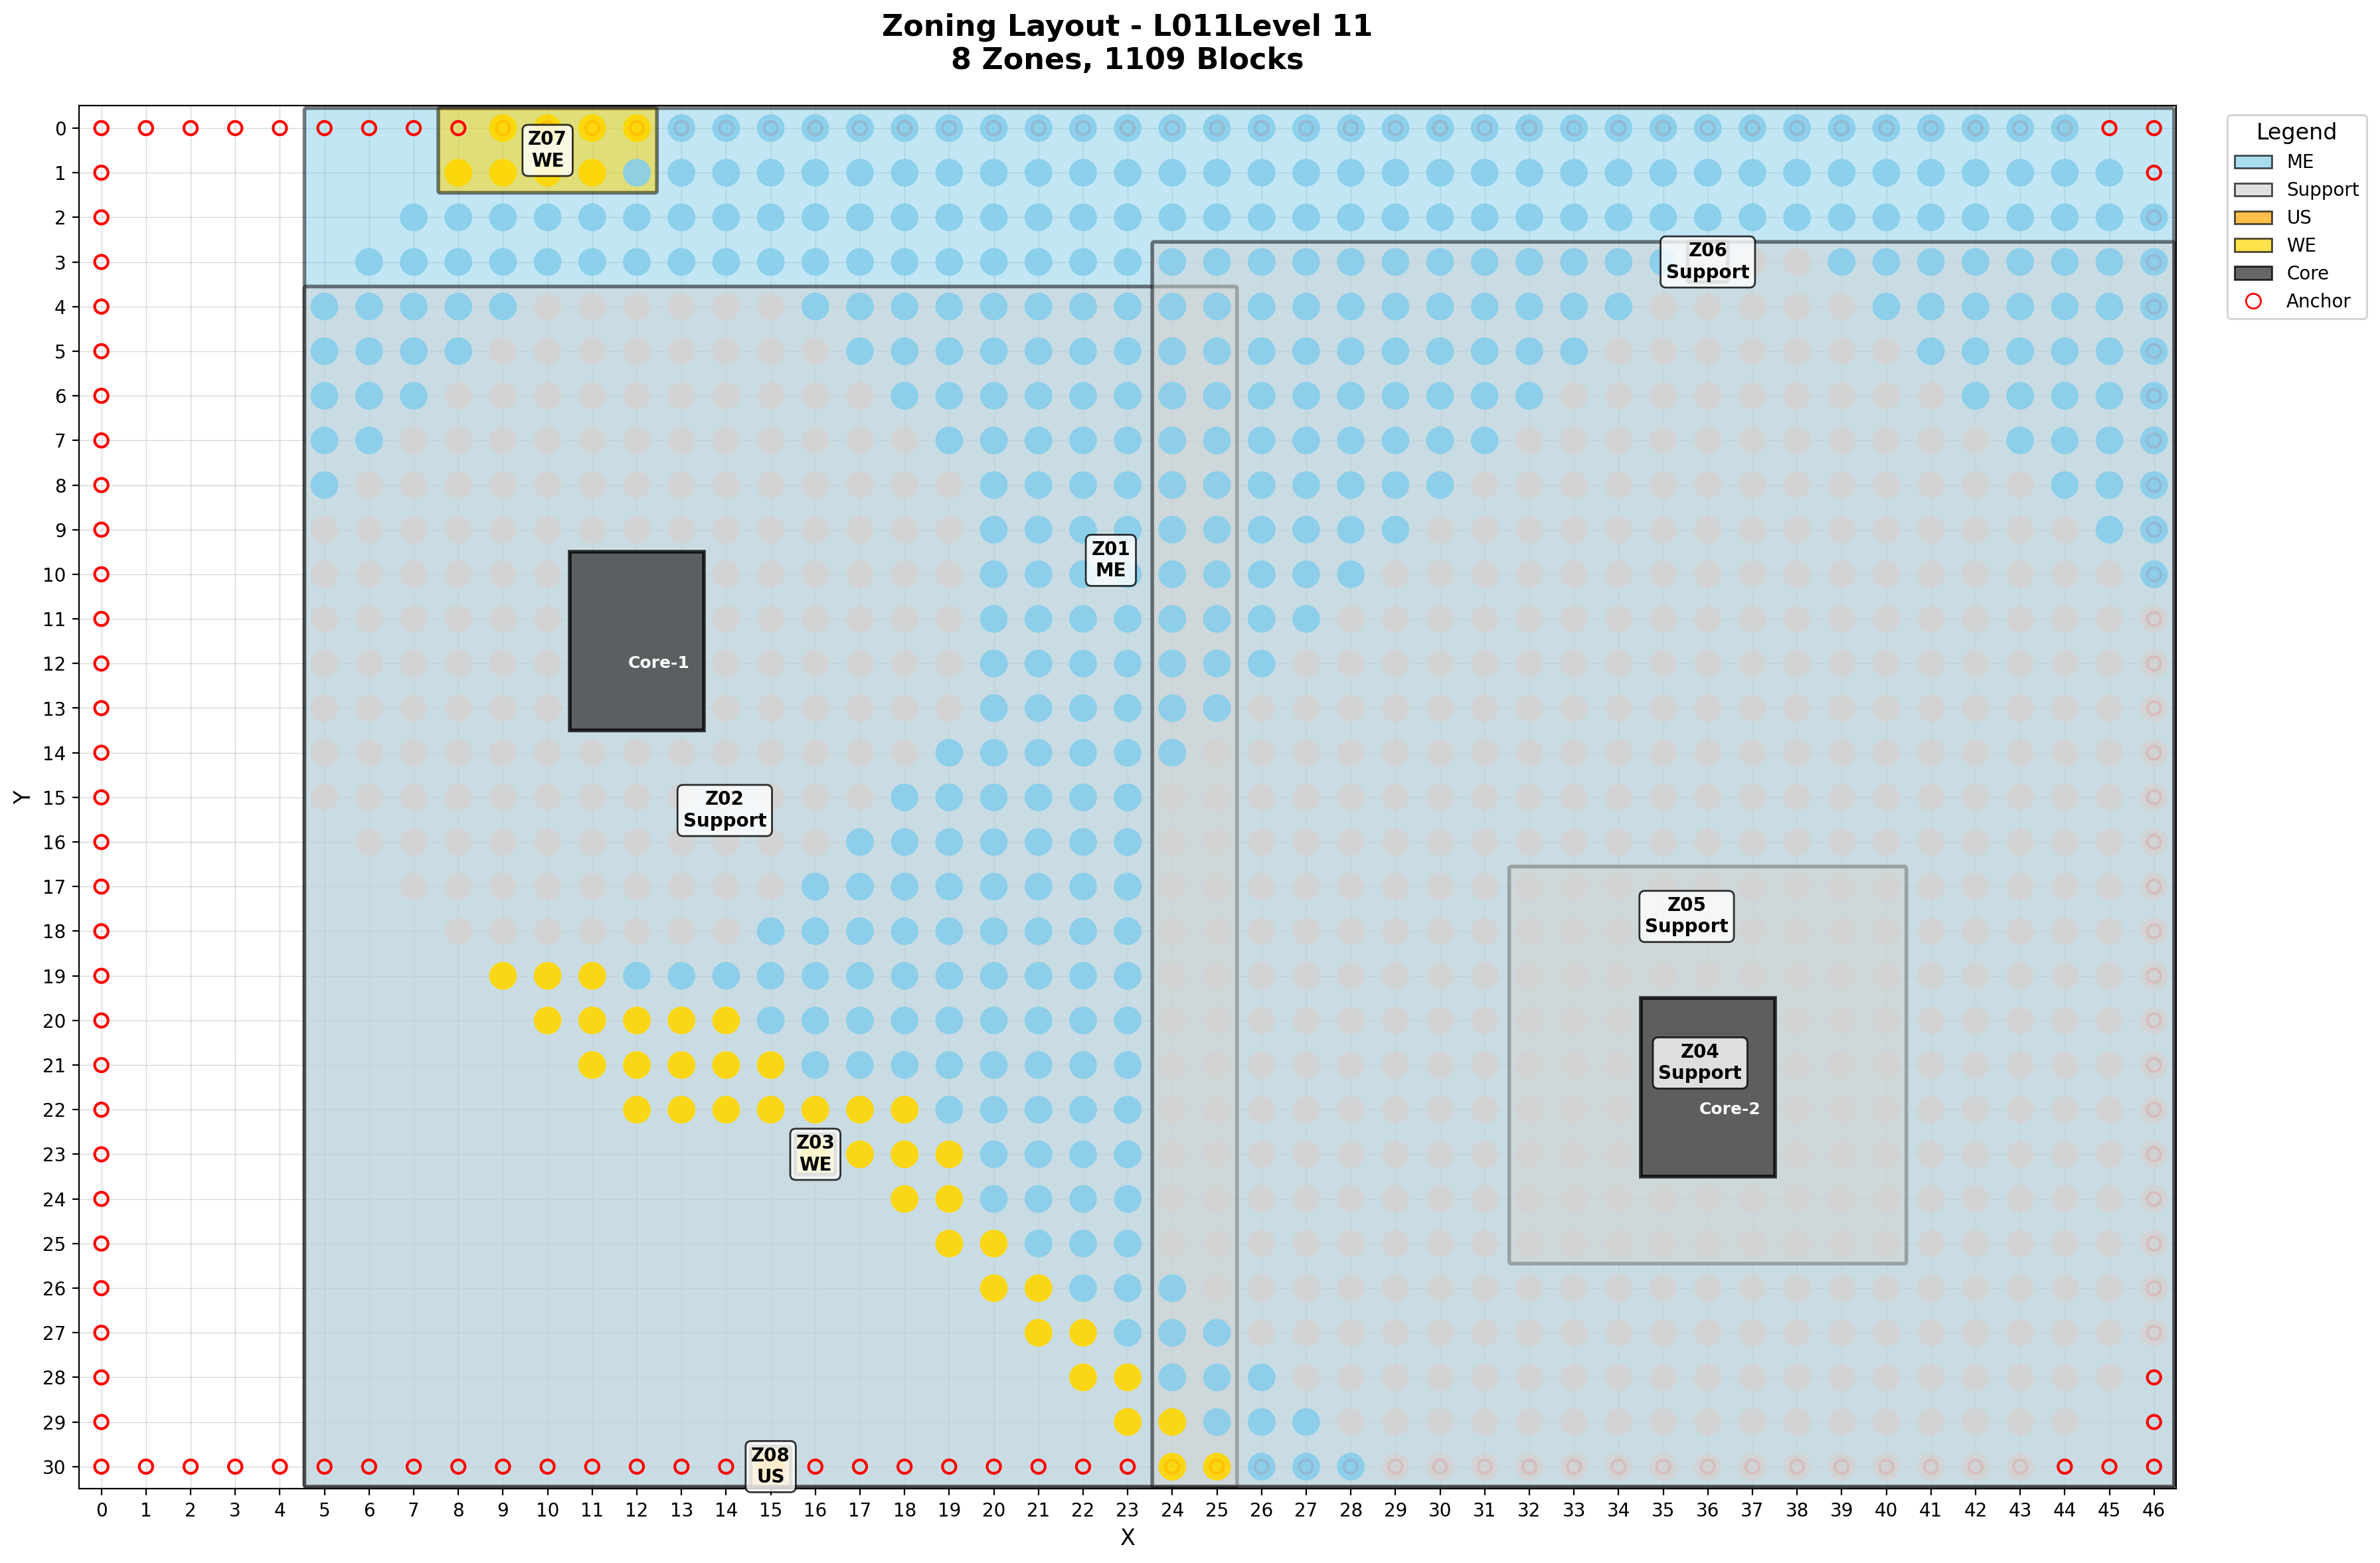

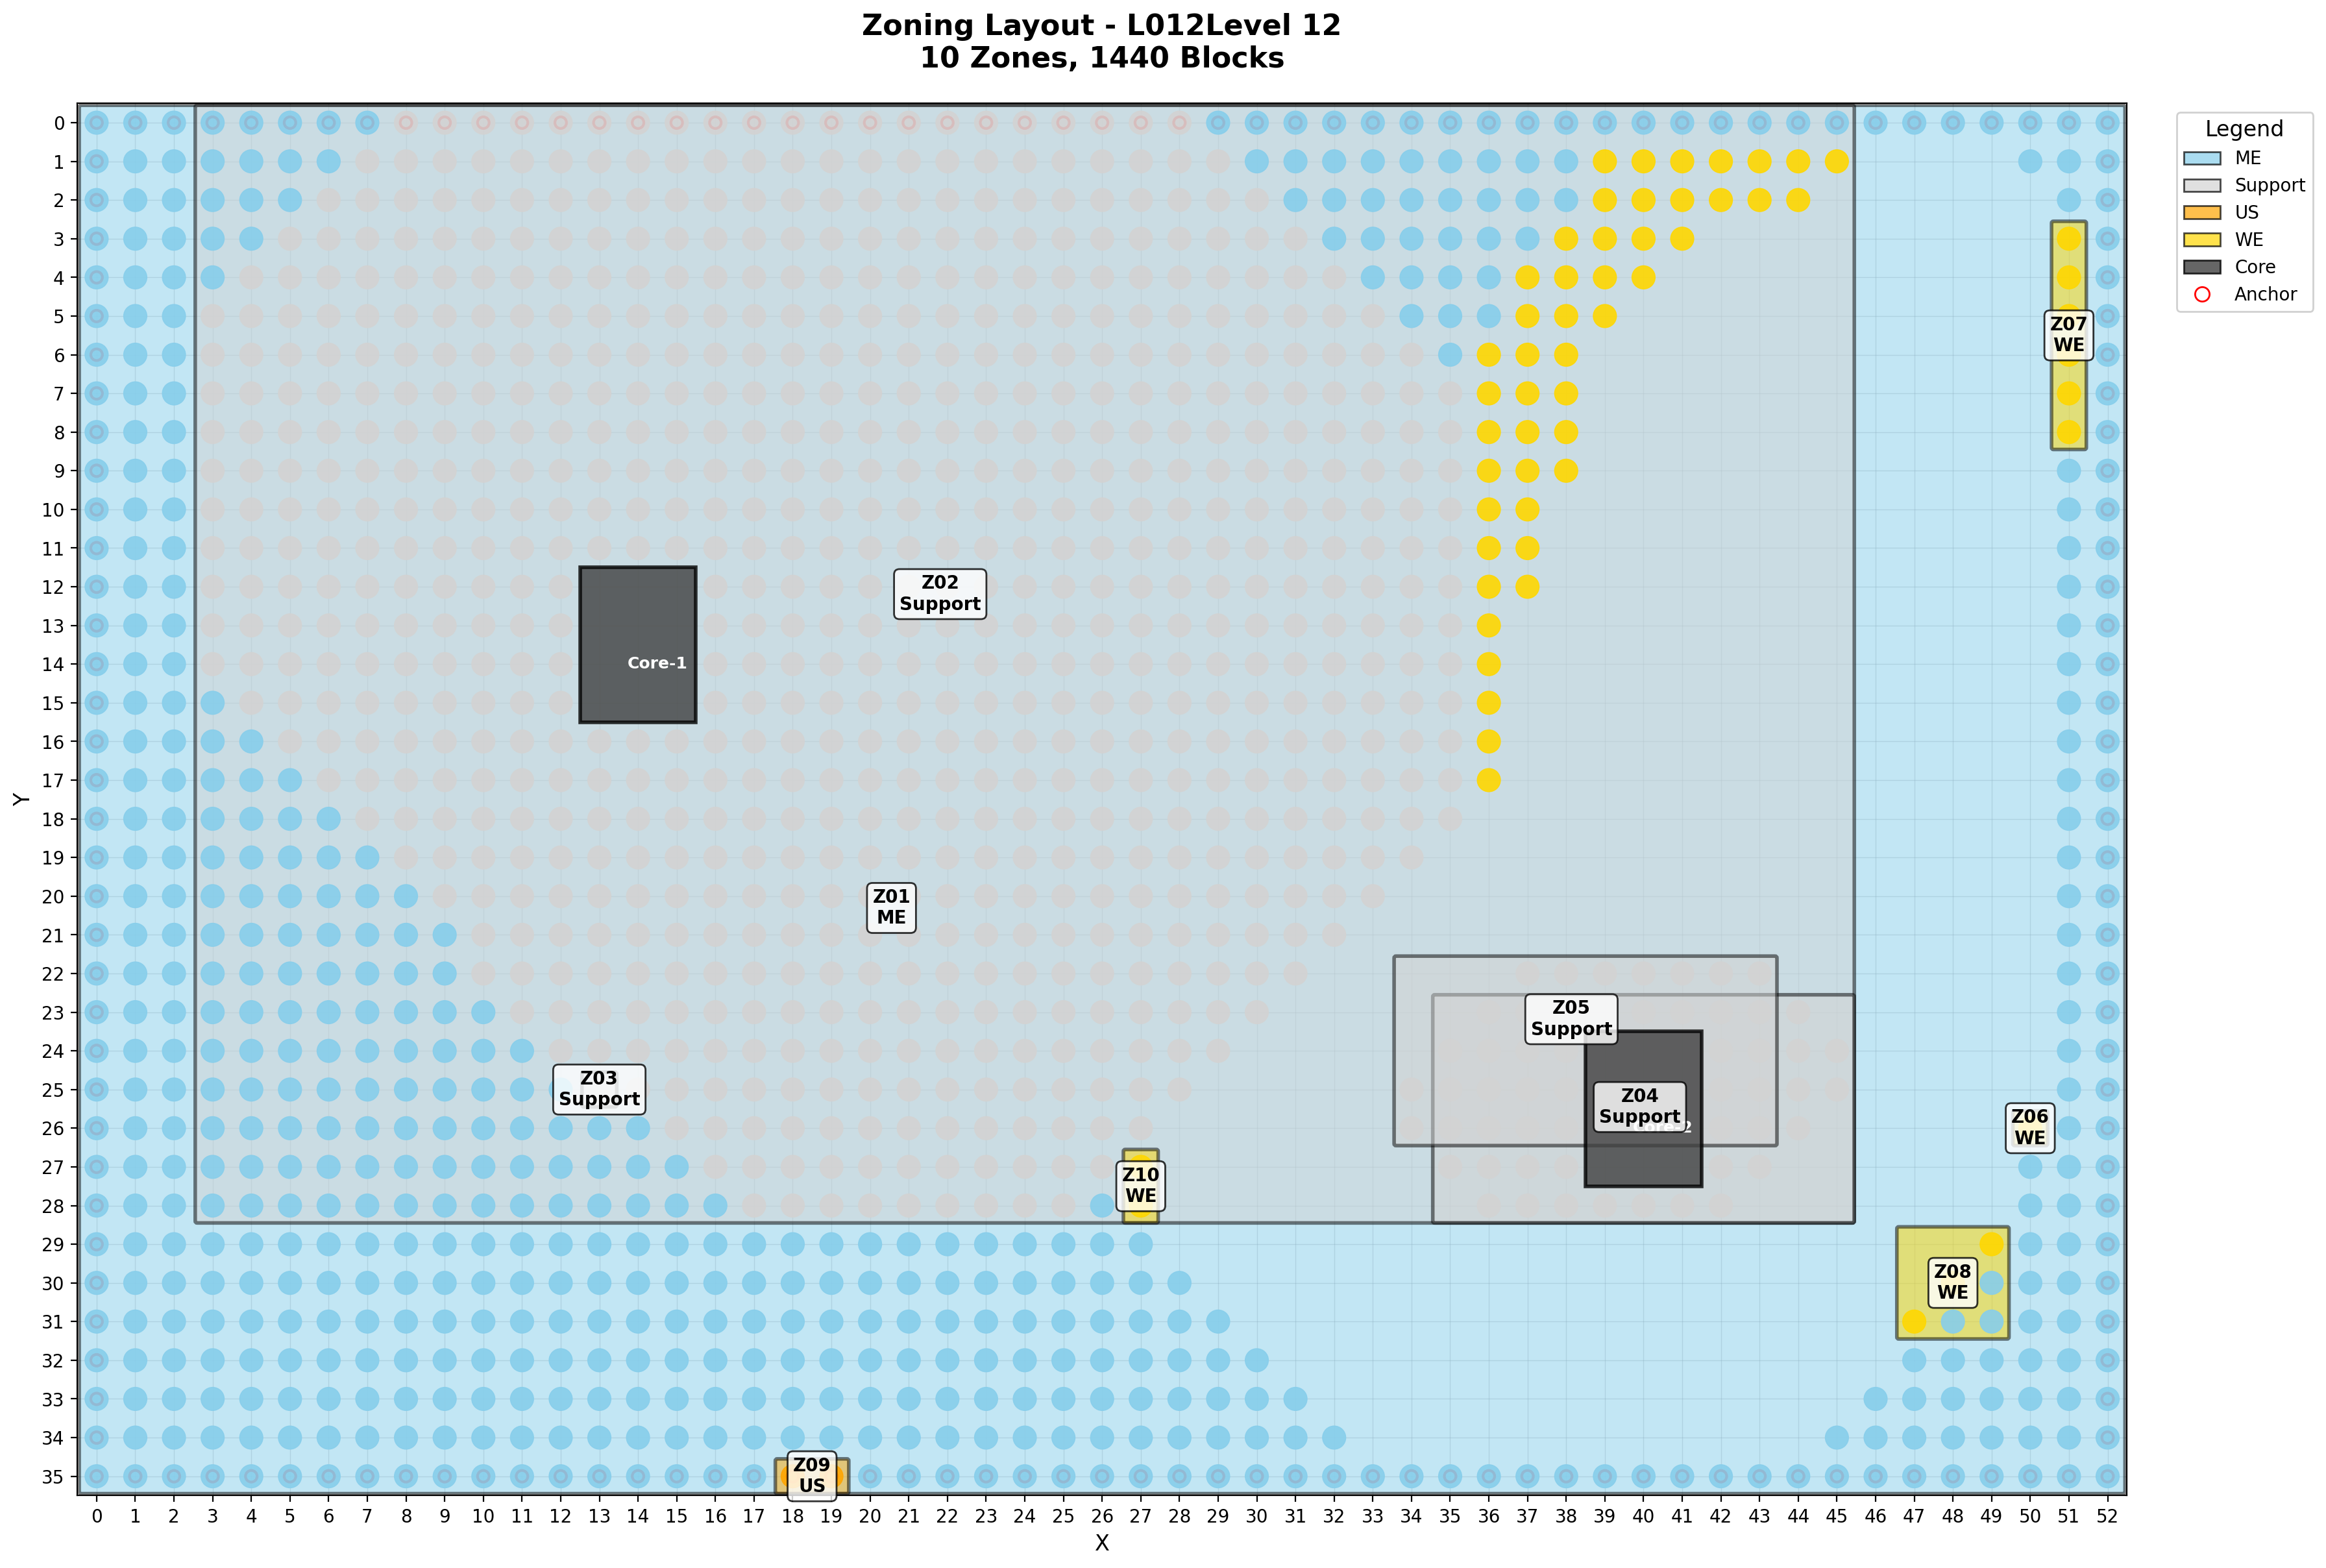